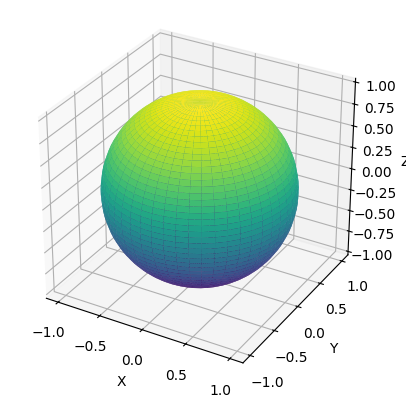

In [75]:
import numpy as np
import matplotlib.pyplot as plt


s = np.linspace(0, 2 * np.pi)
t = np.linspace(0, np.pi)

S, T = np.meshgrid(s, t)

X = np.cos(S) * np.sin(T)
Y = np.sin(S) * np.sin(T)
Z = np.cos(T)

fig = plt.figure()
ax = fig.add_subplot(projection="3d")

ax.plot_surface(X, Y, Z, cmap="viridis")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_aspect('equal')
plt.show()

X = X.flatten()
Y = Y.flatten()
Z =  Z.flatten()


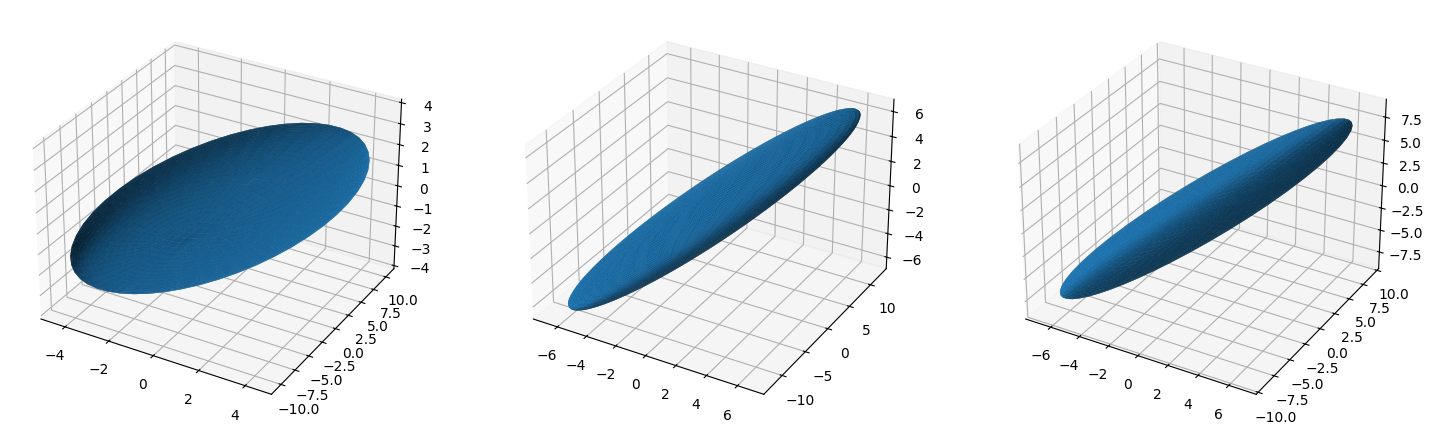

In [76]:
matricies = [np.random.randint(10, size=(3, 3)), np.random.randint(10, size=(3, 3)), np.random.randint(10, size=(3, 3))]


fig = plt.figure(figsize=(18, 6))
for i in range(3):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    plt.axis('equal')
    A = matricies[i] @ [X, Y, Z]
    ax.plot_surface(A[0].reshape(50, 50), A[1].reshape(50, 50),A[2].reshape(50, 50))



#fig.tight_layout()
plt.show()

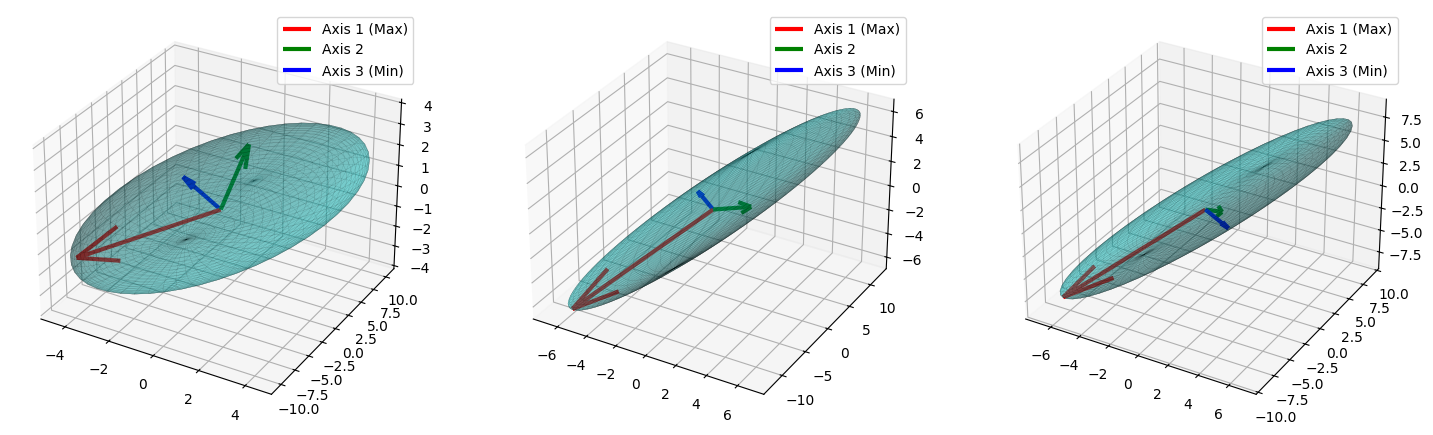

In [77]:
fig = plt.figure(figsize=(18, 6))
points = [X, Y, Z]

for i in range(3):
    A = matricies[i]

    transformed_points = A @ points

    X = transformed_points[0, :].reshape(50, 50)
    Y = transformed_points[1, :].reshape(50, 50)
    Z = transformed_points[2, :].reshape(50, 50)

    U, S_vals, Vt = np.linalg.svd(A)
    
    u1 = U[:, 0] 
    u2 = U[:, 1]
    u3 = U[:, 2]

    axis1 = u1 * S_vals[0]
    axis2 = u2 * S_vals[1]
    axis3 = u3 * S_vals[2]

    origin = [0, 0 ,0]

    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    ax.plot_surface(X, Y, Z, color='c', alpha=0.3, edgecolor='k', linewidth=0.1)

    ax.quiver(*origin, *axis1, color='r', linewidth=3, label='Axis 1 (Max)')
    ax.quiver(*origin, *axis2, color='g', linewidth=3, label='Axis 2')
    ax.quiver(*origin, *axis3, color='b', linewidth=3, label='Axis 3 (Min)')

    ax.legend()

plt.show()

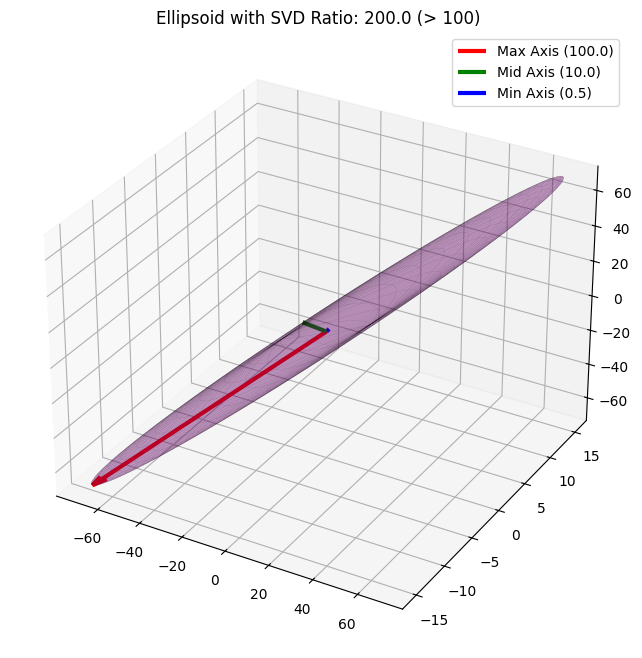

In [97]:
sigma_1 = 100.0
sigma_2 = 10.0
sigma_3 = 0.5

Sigma = np.diag([sigma_1, sigma_2, sigma_3])

U, _ = np.linalg.qr(np.random.randn(3, 3))
Vt, _ = np.linalg.qr(np.random.randn(3, 3))


A = U @ Sigma @ Vt

transformed_points = A @ points

X_new = transformed_points[0, :].reshape(50, 50)
Y_new = transformed_points[1, :].reshape(50, 50)
Z_new = transformed_points[2, :].reshape(50, 50)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')

ax.plot_surface(X_new, Y_new, Z_new, color='m', alpha=0.2, edgecolor='k', linewidth=0.1)

U_res, S_res, Vt_res = np.linalg.svd(A)
axis1 = U_res[:, 0] * S_res[0]
axis2 = U_res[:, 1] * S_res[1]
axis3 = U_res[:, 2] * S_res[2]

origin = [0, 0, 0]
ax.quiver(*origin, *axis1, color='r', linewidth=3, label=f'Max Axis ({S_res[0]:.1f})', arrow_length_ratio=0.05)
ax.quiver(*origin, *axis2, color='g', linewidth=3, label=f'Mid Axis ({S_res[1]:.1f})', arrow_length_ratio=0.05)
ax.quiver(*origin, *axis3, color='b', linewidth=3, label=f'Min Axis ({S_res[2]:.1f})', arrow_length_ratio=0.05)

ax.set_title(f"Ellipsoid with SVD Ratio: {S_res[0]/S_res[2]:.1f} (> 100)")
ax.legend()
plt.show()

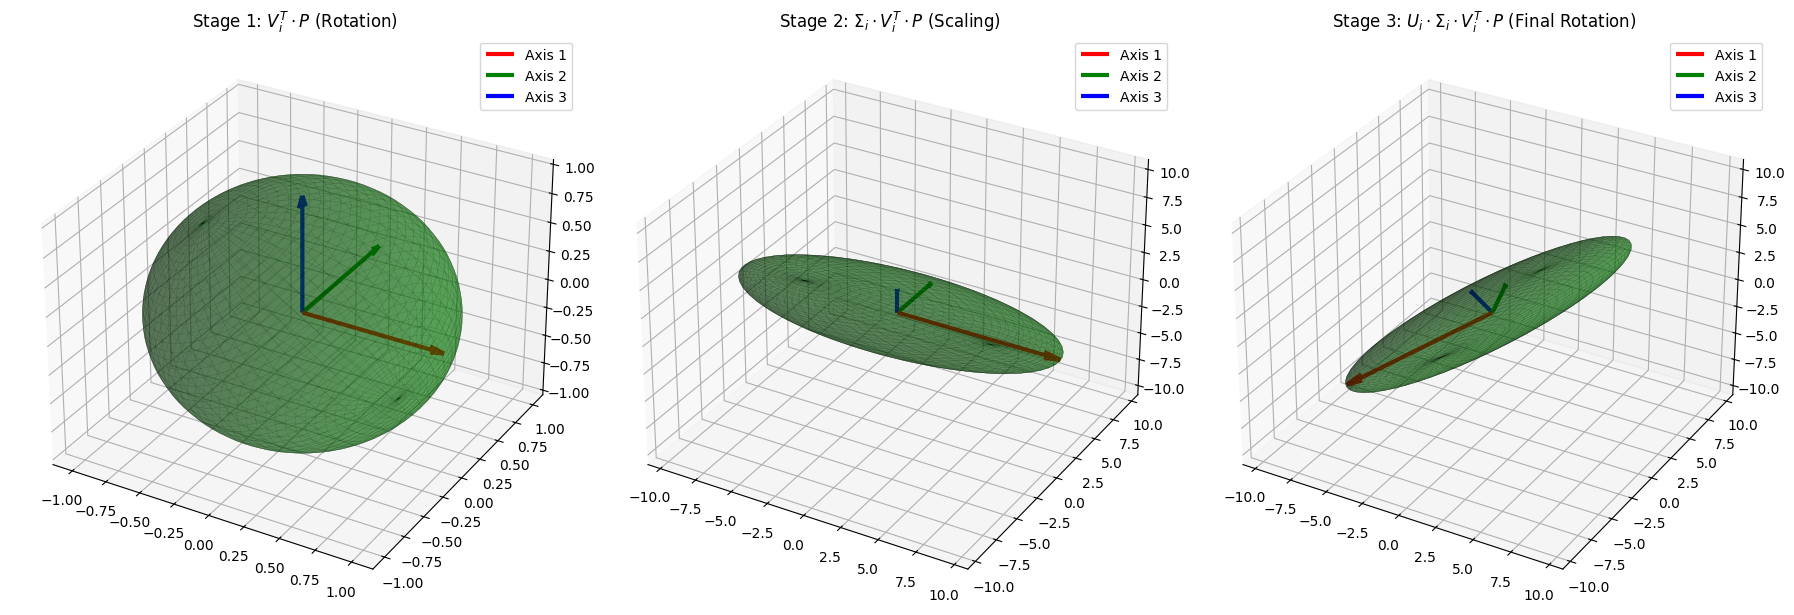

In [ ]:
A = matricies[0]

U, S_vals, Vt = np.linalg.svd(A)
Sigma = np.diag(S_vals)


vecs_start = Vt.T  

stage1_points = Vt @ points
stage2_points = Sigma @ Vt @ points
stage3_points = U @ Sigma @ Vt @ points  

stages = [stage1_points, stage2_points, stage3_points]
titles = [r"Stage 1: $V_i^T \cdot P$ (Rotation)", 
          r"Stage 2: $\Sigma_i \cdot V_i^T \cdot P$ (Scaling)", 
          r"Stage 3: $U_i \cdot \Sigma_i \cdot V_i^T \cdot P$ (Final Rotation)"]

vecs_s1 = Vt @ vecs_start          
vecs_s2 = Sigma @ vecs_s1         
vecs_s3 = U @ vecs_s2              

stage_vectors = [vecs_s1, vecs_s2, vecs_s3]

fig = plt.figure(figsize=(18, 6))
max_radius = np.max(S_vals)

for i in range(3):
    X_stage = stages[i][0, :].reshape(50, 50)
    Y_stage = stages[i][1, :].reshape(50, 50)
    Z_stage = stages[i][2, :].reshape(50, 50)
    
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    ax.plot_surface(X_stage, Y_stage, Z_stage, color='g', alpha=0.4, edgecolor='k', linewidth=0.1)

   
    v1 = stage_vectors[i][:, 0]
    v2 = stage_vectors[i][:, 1]
    v3 = stage_vectors[i][:, 2]
    
    origin = [0, 0, 0]
    ax.quiver(*origin, *v1, color='r', linewidth=3, arrow_length_ratio=0.1, label='Axis 1')
    ax.quiver(*origin, *v2, color='g', linewidth=3, arrow_length_ratio=0.1, label='Axis 2')
    ax.quiver(*origin, *v3, color='b', linewidth=3, arrow_length_ratio=0.1, label='Axis 3')
    if i != 0:
        ax.set_xlim([-max_radius, max_radius])
        ax.set_ylim([-max_radius, max_radius])
        ax.set_zlim([-max_radius, max_radius])
    ax.set_title(titles[i])
    ax.legend()

plt.tight_layout()
plt.show()